# Yield Curve Factor Models and Housing Market Forecasting

A test of whether Treasury yield curve shape predicts housing starts, mortgage rates,
and home prices, using Nelson-Siegel factor extraction and 15 years of out-of-sample
forecasting (2011–2025).

*Adapted from a research paper for Econ 424: Advanced Analytics, Rutgers University.*

Christopher John

## TL;DR

Does the shape of the Treasury yield curve help predict housing market activity? I extracted
level and slope factors from 9 Treasury yield series using a Nelson-Siegel model, then tested
them against a simple "last month predicts this month" (AR(1)) baseline across three targets:
housing starts, 30-year mortgage rates, and home prices.

**The yield curve factors lost.** The AR(1) benchmark produced the lowest forecast error on
all three targets, and the gap was statistically significant for two of them. This suggests that the yield curve factors provide limited additional out-of-sample predictive information beyond the historical behavior of the target variables.

## Key Findings

| Target | Winner | Margin | Statistically Significant?                         |
|---|---|---|----------------------------------------------------|
| Housing Starts | AR(1) | ~0.2–15% lower forecast error vs. competitors | Yes vs. naive/slope-only models; no vs. full model |
| Mortgage Rate | AR(1) | ~3% lower forecast error | No: no model beats chance here                     |
| Home Prices | AR(1) | 4x+ lower forecast error | Yes, decisively (p < 0.001 vs. 3 of 4 models)      |

The home price result is the sharpest: models using only yield curve factors were more than
four times worse than simply extrapolating last month's price momentum. Full detail and the
Diebold-Mariano significance tests are below.

## Methodology

Data comes from the Federal Reserve Economic Database (FRED): 9 Treasury constant maturity
yield series (1-month through 10-year), housing starts (HOUST), the 30-year fixed mortgage
rate(MORTGAGE30US), and the Case-Shiller national home price index(CSUSHPINSA). The sample spans August 2001 through
December 2025 (290 monthly observations). All series are transformed to stationarity, housing
starts and home prices are log-differenced, mortgage rates and yield factors are first-differenced.

In [1]:
#   code cell 1
#import statements
import pandas as pd
import numpy as np
from fredapi import Fred
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from dieboldmariano import dm_test
import os
from dotenv import load_dotenv

In [2]:
#   code cell 2
#data cleaning and processing
load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY'))
#fred = Fred(api_key='')

data = {}

#Get HOUST, original data in thousands of units
HOUST = fred.get_series(series_id='HOUST', observation_start="2001-07-01", observation_end='2025-12-31')

#Get and convert MORTGAGE30US, original data is weekly and in percents -> monthly
mortgage_raw= fred.get_series(series_id='MORTGAGE30US', observation_start="2001-07-01",observation_end='2025-12-31')
mortgage_monthly = mortgage_raw.resample('MS').mean()

# Get CSUSHPINSA, originally Monthly and indexed -> shift forward 2 for publication lag
csushpinsa_raw = fred.get_series(series_id='CSUSHPINSA', observation_start="2001-07-01", observation_end='2025-12-31')
csushpinsa_monthly =csushpinsa_raw.resample('MS').last().shift(2)

#Get Treasury Yields, originally daily and in percents -> monthly
interest_rates = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10']
treasury_data = {}

for rate in interest_rates:
    raw = fred.get_series(rate, observation_start="2001-07-01", observation_end='2025-12-31')
    treasury_data[rate] = raw.resample('MS').mean()

treasury_df = pd.DataFrame(treasury_data)


# merge the data
df = treasury_df.copy()
df["HOUST"] = HOUST
df["MORTGAGE30US"] = mortgage_monthly
df["CSUSHPINSA"] = csushpinsa_monthly
df.dropna(inplace=True)

## Yield Curve Factor Extraction

The Nelson-Siegel model is applied to the 9 Treasury yield series each month, using OLS to
extract two latent factors: **level** (the overall height of the yield curve) and **slope**
(the spread between long and short rates). The decay parameter is fixed at λ = 0.0609,
following Diebold and Li (2006).

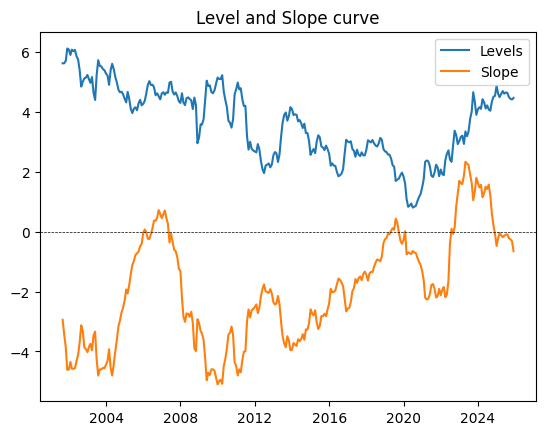

In [3]:
#   code cell 3
#nelson siegel implementaiton
    # convert maturities into months
maturities  = np.array([1, 3, 6, 12, 24, 36, 60, 84, 120])

lam = 0.0609

def ns_loadings(tau,lam):
    # L = levels, S = slope, C = curvature
    L = np.ones(len(tau))
    S = (1- np.exp(-lam * tau)) / (lam * tau)
    C = S - np.exp(-lam * tau)
    return np.column_stack([L,S,C])

# fixed loading matrix
X_ns = ns_loadings(maturities,lam)

betas = []

# Fit OLS to extract betas
for date, row in df[interest_rates].iterrows():
    y_curve = row.values
    # OLS: beta = (X'X)^-1 X'y
    beta = np.linalg.lstsq(X_ns, y_curve, rcond = None)[0]
    betas.append(beta)

betas_df = pd.DataFrame(betas,
                        index = df.index,
                        columns = ['beta1_L', 'beta2_S', 'beta3_C'])

# add facotrs to main df
df['f1'] = betas_df['beta1_L']
df['f2'] = betas_df['beta2_S']

#visualize factors
plt.plot(df.index, df['f1'], label='Levels')
plt.plot(df.index, df['f2'], label='Slope')
plt.axhline(0, color='black', linewidth = 0.5, linestyle = '--')
plt.title('Level and Slope curve')
plt.legend()
plt.show()

In [4]:
#   code cell 4
# differencing and logging of all series
df['df1'] = df['f1'].diff()
df['df2'] = df['f2'].diff()
    #change in % points
df['dMORTGAGE30US'] = df['MORTGAGE30US'].diff()


    # log difference HOUST and CSUSHIPINSA
    # monthly % changes in starts and prices
    # one unit factor change means % change
df['dHOUST'] = np.log(df['HOUST']).diff()
df['dCSUSHPINSA'] = np.log(df['CSUSHPINSA']).diff()

df.dropna(inplace=True)



# Create all lags explicitly before the loop
df['df1_lag']          = df['df1'].shift(1)
df['df2_lag']          = df['df2'].shift(1)
df['dY_lag_HOUST']     = df['dHOUST'].shift(1)
df['dY_lag_MORTGAGE']  = df['dMORTGAGE30US'].shift(1)
df['dY_lag_CSUSHPINSA']= df['dCSUSHPINSA'].shift(1)

# Single dropna — all lags created simultaneously so only one row lost
df.dropna(inplace=True)

# establish training and testing datasets
train_end = '2010-12-01'
test_start = '2011-01-01'
train_df    = df[df.index <= train_end].copy()
test_df     = df[df.index >= test_start].copy()

# Map each dependent variable to its correct lag column
dependent_vars = {
    'HOUST':      ('dHOUST',       'dY_lag_HOUST'),
    'MORTGAGE':   ('dMORTGAGE30US','dY_lag_MORTGAGE'),
    'CSUSHPINSA': ('dCSUSHPINSA',  'dY_lag_CSUSHPINSA')
}

models = {
    'M1': [],                              # constant only — no-change benchmark
    'M2': ['dY_lag'],                      # AR(1) — own lag only
    'M3': ['df2_lag'],                     # slope factor only
    'M4': ['df1_lag', 'df2_lag'],          # level + slope factors
    'M5': ['df1_lag', 'df2_lag', 'dY_lag'] # full model — factors + AR(1)
}

results = {}


## In-Sample Regression Results

Five models of increasing complexity, from a naive intercept-only model up to a full model
combining both yield curve factors with an AR(1) term, are estimated in-sample (2001-2010)
for each target variable. These results show what the yield curve factors could explain
historically, before testing whether that translates into real forecasting power.
Representative regression output is shown below. The same estimation procedure was applied to all model specifications and dependent variables. Complete model comparisons are summarized in the forecasting evaluation tables presented later.
The notebook can be easily modified to display all regression summaries if a more detailed inspection is desired.

In [5]:
#   code cell 5
#Regressions
for dep_name, (dep_col, dep_lag_col) in dependent_vars.items():
    results[dep_name] = {}

    # Temporarily assign the correct lag to dY_lag for this dependent variable
    train_df['dY_lag'] = train_df[dep_lag_col]
    train_clean = train_df.copy()

    for model_name, predictors in models.items():

        y = train_clean[dep_col]

        if predictors:
            X = sm.add_constant(train_clean[predictors])
        else:
            X = pd.DataFrame(
                {'const': np.ones(len(train_clean))},
                index=train_clean.index
            )

        model = sm.OLS(y, X).fit()
        results[dep_name][model_name] = model


        if dep_name == "HOUST" and model_name == "M2":
            print(f"\n{'='*60}")
            print(f"Dependent Variable: {dep_name} | Model: {model_name}")
            print(f"{'='*60}")
            print(model.summary())



Dependent Variable: HOUST | Model: M2
                            OLS Regression Results                            
Dep. Variable:                 dHOUST   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     5.684
Date:                Tue, 21 Jul 2026   Prob (F-statistic):             0.0189
Time:                        14:29:33   Log-Likelihood:                 129.16
No. Observations:                 110   AIC:                            -254.3
Df Residuals:                     108   BIC:                            -248.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

## Out-of-Sample Forecasting

Each model is re-estimated recursively: starting with the initial 2001-2010 training window,
one observation is added at a time, the model is refit, and a one-step-ahead forecast is
generated. This repeats across 180 months (January 2011 to December 2025), simulating how
each model would have actually performed making real-time predictions.

In [6]:
#   code cell 6
# Recursive Forecasting
forecast_results = {}

for dep_name, (dep_col, dep_lag_col) in dependent_vars.items():

    forecast_results[dep_name] = {}

    test_df = df[df.index >= test_start].copy()
    test_df['dY_lag'] = test_df[dep_lag_col]

    for model_name, predictors in models.items():

        forecasts = []
        actuals   = []
        dates     = []

        for i in range(len(test_df)):

            # expanding window: cutoff grows by one month each iteration,
            # starting right after the training period ends
            cutoff = test_df.index[i - 1] if i > 0 else pd.Timestamp(train_end)

            window = df.loc[:cutoff].copy()

            window['dY_lag'] = window[dep_lag_col]

            y_train = window[dep_col]

            if predictors:
                X_train = sm.add_constant(window[predictors])
            else:
                X_train = pd.DataFrame(
                    {'const': np.ones(len(window))},
                    index=window.index
                )
            # refit on the expanding window, forecast one step ahead
            model_fit = sm.OLS(y_train, X_train).fit()

            # single test point to forecast — pulled out as its own row
            test_point = test_df.iloc[i]

            if predictors:
                X_forecast = pd.DataFrame(
                    [test_point[predictors].values],
                    columns=predictors
                )
                # has_constant='add' since a 1-row frame won't infer the constant on its own
                X_forecast = sm.add_constant(X_forecast, has_constant='add')
            else:
                X_forecast = pd.DataFrame({'const': [1.0]})

            forecast = model_fit.predict(X_forecast)[0]

            forecasts.append(forecast)
            actuals.append(test_df[dep_col].iloc[i])
            dates.append(test_df.index[i])

        forecast_results[dep_name][model_name] = pd.DataFrame({
            'forecast': forecasts,
            'actual':   actuals,
            'error':    np.array(actuals) - np.array(forecasts)
        }, index=dates)

    print(f"Completed forecasts for {dep_name}")

print("All recursive forecasts complete")

Completed forecasts for HOUST
Completed forecasts for MORTGAGE
Completed forecasts for CSUSHPINSA
All recursive forecasts complete


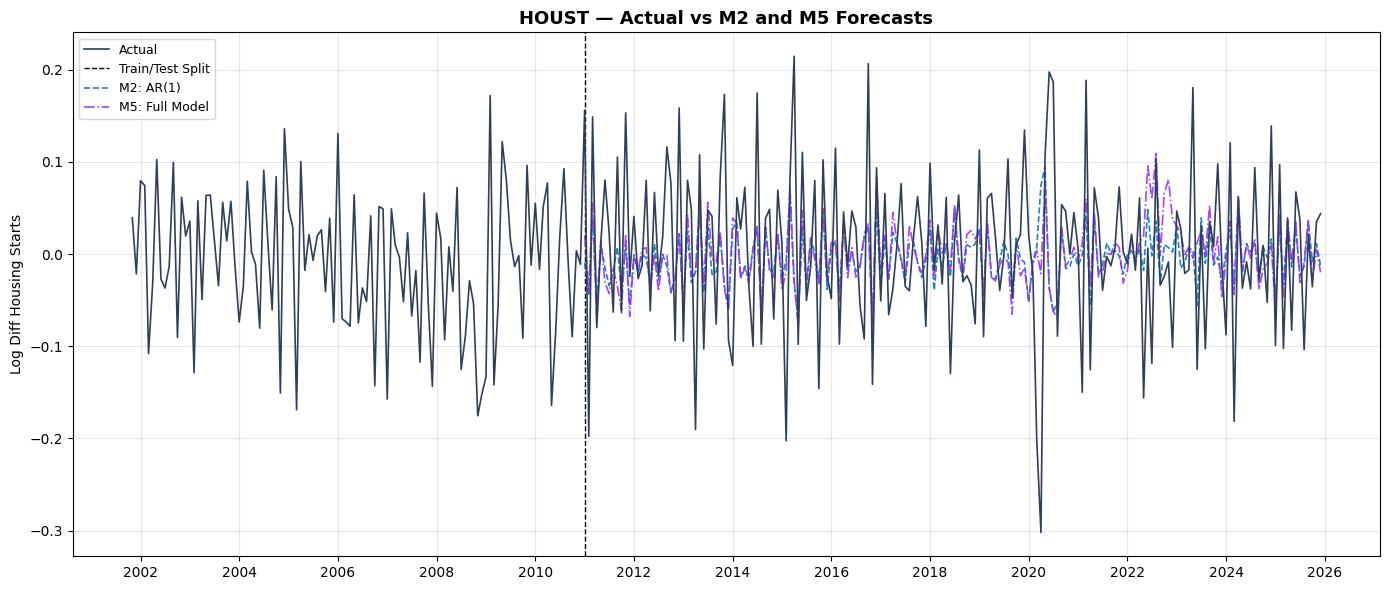

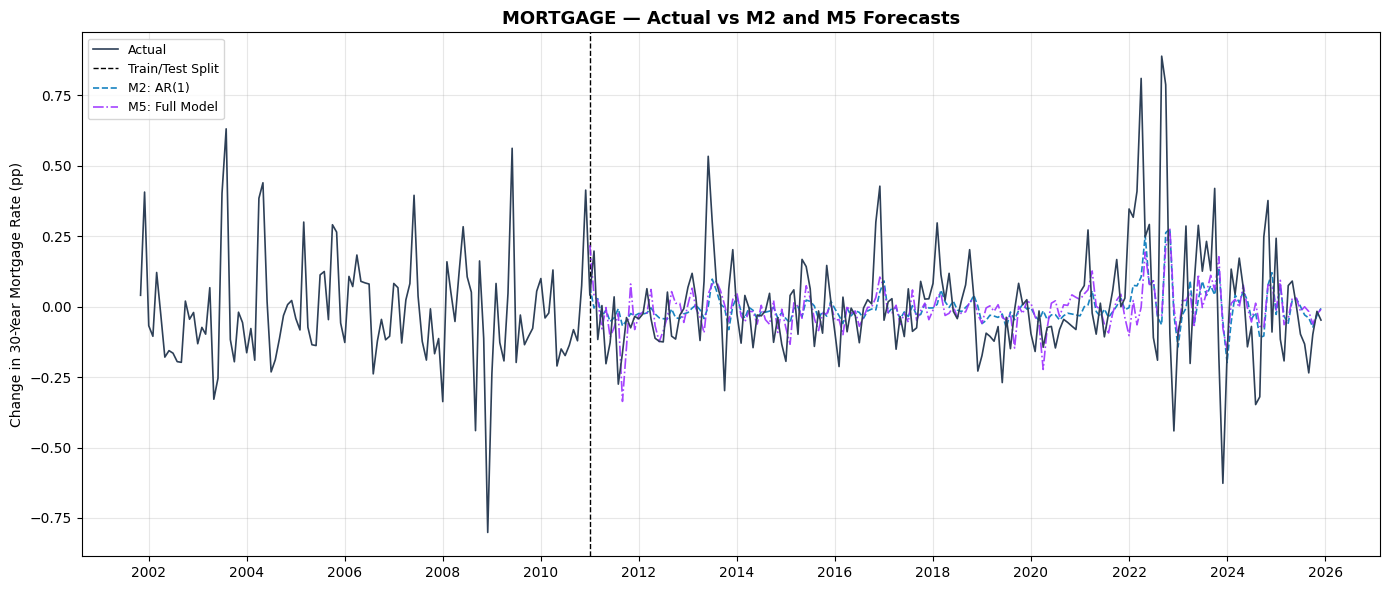

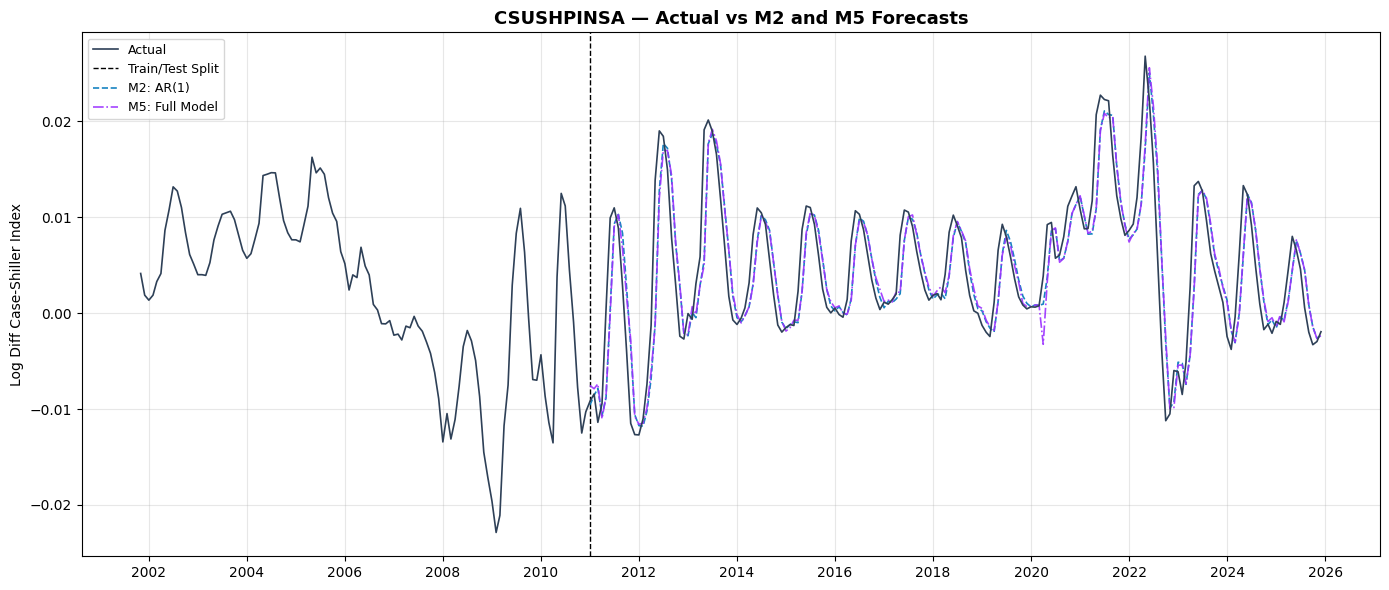

In [7]:
#   code cell 7
colors = {
    'actual':  '#2E4057',   # dark navy — actual data
    'M1':      '#E63946',   # red
    'M2':      '#0077BB',   # blue
    'M3':      '#228B22',   # green
    'M4':      '#FF6F00',   # orange
    'M5':      '#9B30FF',   # purple
    'residual':'#E63946',   # bright red
    'zero':    '#000000'    # black
}

dep_labels = {
    'HOUST':      'Log Diff Housing Starts',
    'MORTGAGE':   'Change in 30-Year Mortgage Rate (pp)',
    'CSUSHPINSA': 'Log Diff Case-Shiller Index'
}



# Forecast vs Actual Plots (M2 and M5 only)
for dep_name, (dep_col, dep_lag_col) in dependent_vars.items():

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(df.index, df[dep_col],
            color=colors['actual'], linewidth=1.2,
            label='Actual', zorder=5)

    ax.axvline(pd.Timestamp(test_start), color='black',
               linestyle='--', linewidth=1.0, label='Train/Test Split')

    fc_m2 = forecast_results[dep_name]['M2']
    ax.plot(fc_m2.index, fc_m2['forecast'],
            color=colors['M2'], linewidth=1.2,
            alpha=0.9, label='M2: AR(1)',
            linestyle='--')

    fc_m5 = forecast_results[dep_name]['M5']
    ax.plot(fc_m5.index, fc_m5['forecast'],
            color=colors['M5'], linewidth=1.2,
            alpha=0.9, label='M5: Full Model',
            linestyle='-.')

    ax.set_title(f'{dep_name} — Actual vs M2 and M5 Forecasts',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel(dep_labels[dep_name], fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Forecast Error Distributions

Beyond average forecast error, the distribution of errors across models tells its own story.
Tighter, more centered distributions indicate more reliable predictions. The boxplots below
show model M2 (AR(1)) consistently produces the tightest, most centered error distribution,
especially for home prices.

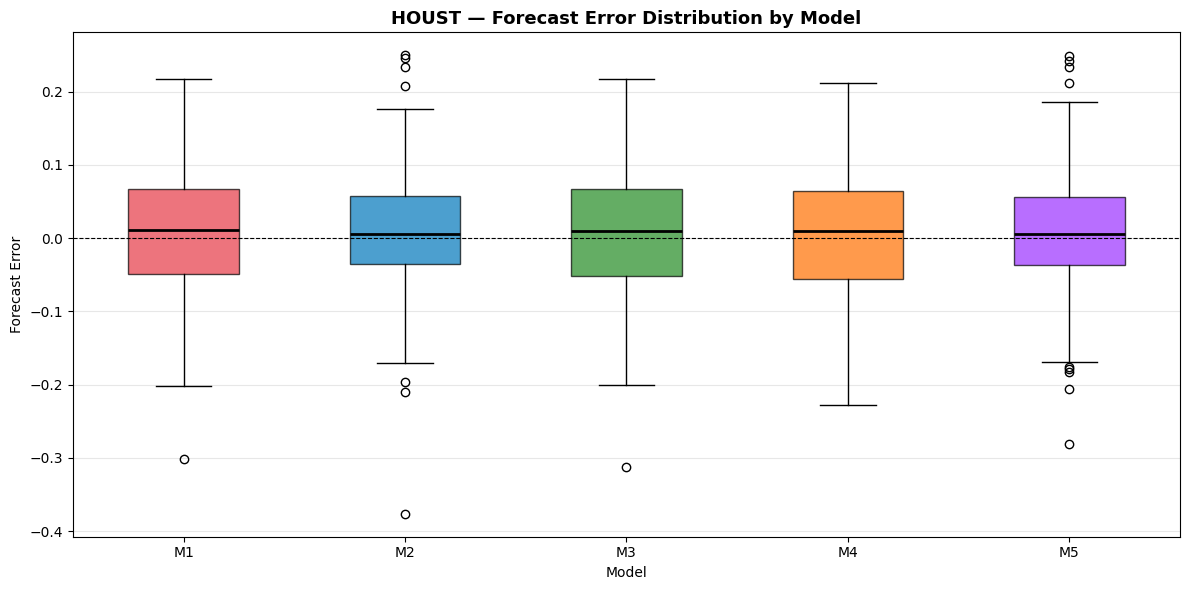

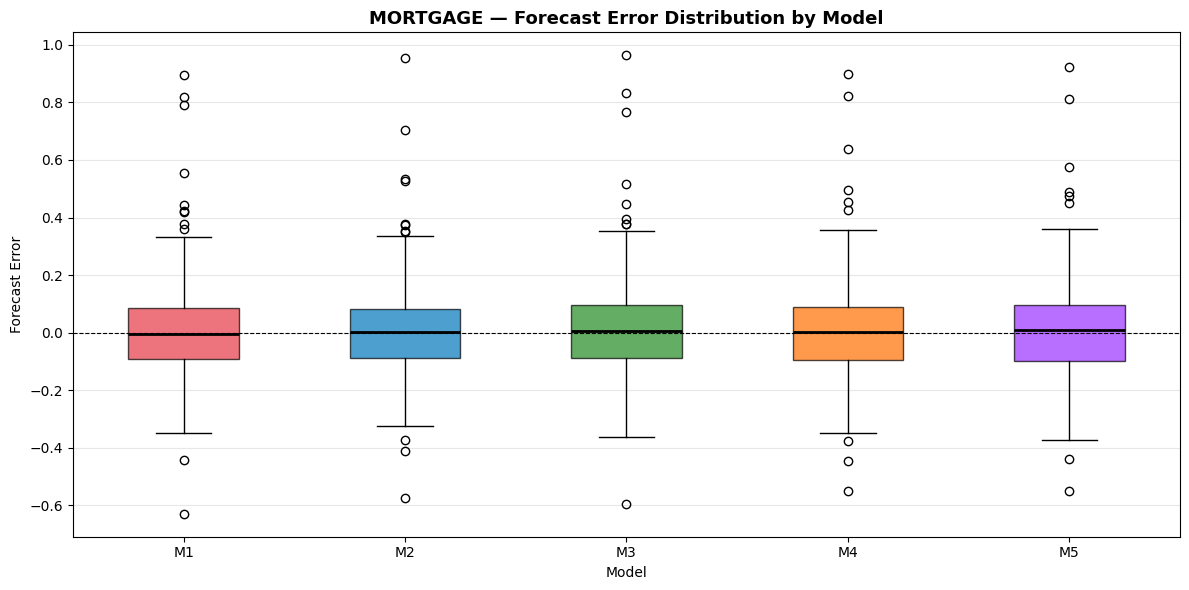

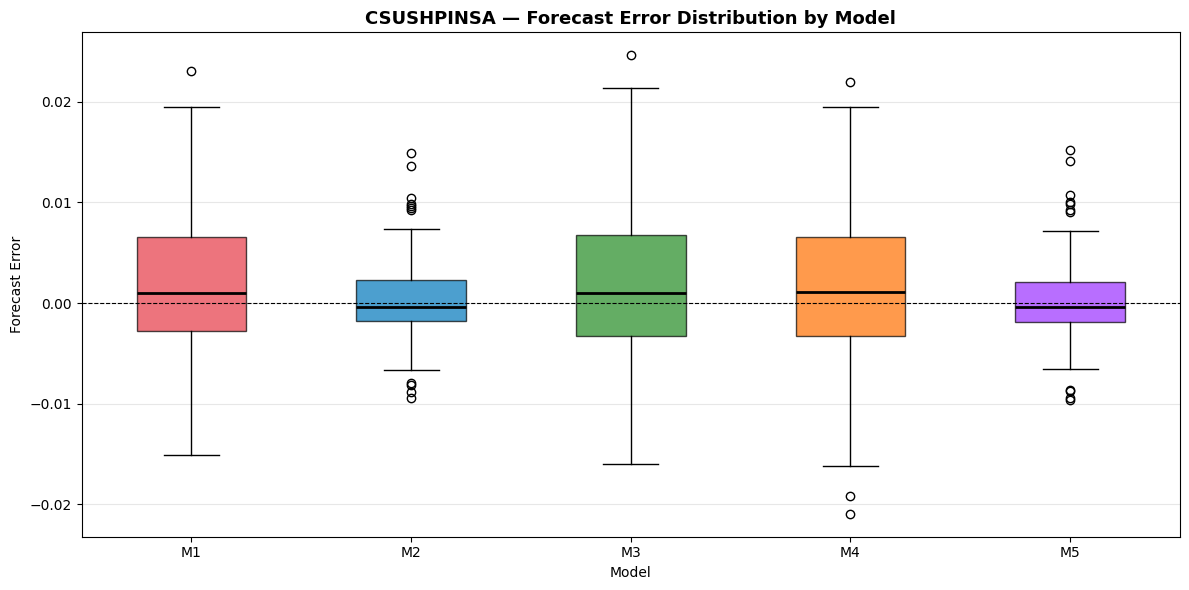

In [8]:
#   code cell 8
#   Forecast Error Boxplots
for dep_name in dependent_vars.keys():

    fig, ax = plt.subplots(figsize=(12, 6))

    error_data  = []
    model_names = []

    for model_name in models.keys():
        errors = forecast_results[dep_name][model_name]['error']
        error_data.append(errors.values)
        model_names.append(model_name)

    bp = ax.boxplot(error_data, tick_labels=model_names, patch_artist=True, medianprops=dict(color='black', linewidth=2))

    model_color_list = [colors[m] for m in model_names]
    for patch, color in zip(bp['boxes'], model_color_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{dep_name} — Forecast Error Distribution by Model',
                     fontsize=13, fontweight='bold')
    ax.set_ylabel('Forecast Error', fontsize=10)
    ax.set_xlabel('Model', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

## Forecast Accuracy: MSFE and Statistical Significance

The table below reports Mean Square Forecast Error (MSFE) for each model and target. The
Diebold-Mariano test formally checks whether differences in forecast accuracy are statistically
meaningful or just noise, using model M2 (AR(1)) as the benchmark.

In [9]:
#   code cell 9
# MSFE computation and printing
def compute_msfe(forecast_results, dependent_vars, models):

    msfe_results = {}

    for dep_name in dependent_vars.keys():
        msfe_results[dep_name] = {}
        for model_name in models.keys():
            errors = forecast_results[dep_name][model_name]['error']
            msfe = (errors ** 2).mean()
            msfe_results[dep_name][model_name] = msfe

    return pd.DataFrame(msfe_results)

msfe_df = compute_msfe(forecast_results, dependent_vars, models)
print("\nMSFE Results:")
print(msfe_df.round(6))

print("\nBest model per dependent variable:")
print(msfe_df.idxmin())


MSFE Results:
       HOUST  MORTGAGE  CSUSHPINSA
M1  0.008203  0.037534    0.000060
M2  0.007046  0.033001    0.000014
M3  0.008259  0.035976    0.000062
M4  0.008300  0.033972    0.000065
M5  0.007055  0.034793    0.000015

Best model per dependent variable:
HOUST         M2
MORTGAGE      M2
CSUSHPINSA    M2
dtype: str


In [10]:
#   code cell 10
#   Diebold-Mariano Test
def compute_dm_test(forecast_results, dependent_vars, models, benchmark='M2'):

    dm_results = {}

    for dep_name in dependent_vars.keys():
        dm_results[dep_name] = {}

        actuals = forecast_results[dep_name][benchmark]['actual'].values
        benchmark_forecasts = forecast_results[dep_name][benchmark]['forecast'].values

        for model_name in models.keys():

            if model_name == benchmark:
                dm_results[dep_name][model_name] = {
                    'DM Stat':    '-',
                    'p-value':    '-',
                    'Conclusion': 'Benchmark'
                }
                continue

            model_forecasts = forecast_results[dep_name][model_name]['forecast'].values

            dm_stat, p_value = dm_test(actuals,
                                       benchmark_forecasts,
                                       model_forecasts,
                                       h=1,
                                       harvey_correction=True,
                                       variance_estimator='bartlett')

            if p_value < 0.05:
                conclusion = f'{model_name} significantly better' if dm_stat > 0 else 'M2 significantly better'
            else:
                conclusion = 'No significant difference'

            dm_results[dep_name][model_name] = {
                'DM Stat':    round(dm_stat, 4),
                'p-value':    round(p_value, 4),
                'Conclusion': conclusion
            }

    return dm_results

#   DM test Results
dm_results = compute_dm_test(forecast_results, dependent_vars, models)
print("\nDiebold-Mariano Test Results:")
for dep_name, comparisons in dm_results.items():
    print(f"\n{dep_name}:")
    print(pd.DataFrame(comparisons).T)


Diebold-Mariano Test Results:

HOUST:
   DM Stat p-value                 Conclusion
M1  -2.492  0.0136    M2 significantly better
M2       -       -                  Benchmark
M3 -2.7462  0.0066    M2 significantly better
M4 -1.8624  0.0642  No significant difference
M5 -0.0205  0.9837  No significant difference

MORTGAGE:
   DM Stat p-value                 Conclusion
M1 -1.7015  0.0906  No significant difference
M2       -       -                  Benchmark
M3 -1.2066  0.2292  No significant difference
M4 -0.5551  0.5795  No significant difference
M5 -1.2048  0.2299  No significant difference

CSUSHPINSA:
   DM Stat p-value               Conclusion
M1 -7.2698     0.0  M2 significantly better
M2       -       -                Benchmark
M3 -7.0324     0.0  M2 significantly better
M4 -7.3011     0.0  M2 significantly better
M5 -1.9965  0.0474  M2 significantly better


## Conclusion

Yield curve factors carry real explanatory power in-sample, the level factor especially, for
mortgage rates and home prices. But that explanatory power does not survive the jump to genuine
out-of-sample forecasting. A simple AR(1) model beats every yield-curve-augmented model across
all three targets, with the gap statistically significant for housing starts and home prices.

This suggests that the yield curve factors provide limited additional out-of-sample predictive information beyond the historical behavior of the target variables. This is consistent with the efficient market hypothesis: publicly available information, including the shape of the yield curve, may already be incorporated into market expectations by the time it would otherwise be useful for prediction. It's also a useful reminder that a model's in-sample fit doesn't guarantee forecasting value; the AR(1) benchmark, despite its simplicity, remained hard to beat.